# Mappeoppgave - Del 1.1, IIRA2001 - Høst 2023

## Populasjonsvekst

Ålesund kommune står i fare for å bli pålagt byggestopp, på bakgrunn av den kritiske renseanlegg situasjonen. Politikere og boligutviklere mener det er grunn til å frykte for konsekvensene av en eventuell byggestopp, og det vil være en problemstilling om man vil klare å tilfredsstille etterspørselen etter nye boliger. Det kan derfor være relevant å se på befolkningsutviklingen i Ålesund kommune, og sammenligne denne med tilveksten av nye boliger.

### Populasjonsvekst Ålesund
Ålesund har hatt en svært god befolkningsvekst de siste ti årene, over nasjonal trend. Men da veksten de siste årene har vært avtagende, benytter jeg kun data fra de siste 5 årene, for å danne et mer realistisk bilde for de neste 5 årene. Det er samt spådd nedgang i forhold til de siste 10 år, hos folkeveksten i Ålesund frem til 2045. I gjennomsnittlig befolkningsvekst har jeg hentet tall fra utgangen av alle kvartaler de siste 5 årene. Gjennomsnittlig befolkningtall inneholder folketall ved utgangen av de siste 5 år.

In [3]:
gjennomsnittlig_befolkningsvekst_2018_2022 = (130+111+44+360+125+27+5+236+144+104+-46+190+196+122+146+2+136)/5
gjennomsnittlig_befolkningtall_2018_2022 = (65633+66273+66670+67114+67520)/5
gjennomsnittlig_befolkningsvekst_2018_2022_desimal = round(gjennomsnittlig_befolkningsvekst_2018_2022/gjennomsnittlig_befolkningtall_2018_2022, 4)
print(gjennomsnittlig_befolkningsvekst_2018_2022)
print(gjennomsnittlig_befolkningtall_2018_2022)
print(gjennomsnittlig_befolkningsvekst_2018_2022_desimal)

406.4
66642.0
0.0061


In [4]:
def populasjonsvekst(r, startpopulasjon, tid):
    return startpopulasjon*(1+r)**tid

def populasjonsvekst_liste(r, startpopulasjon, sluttid):
    befolkningsliste=[]
    for tidspunkt in range(sluttid):
        befolkningsliste.append(round(populasjonsvekst(r,startpopulasjon,tidspunkt)))    
    return befolkningsliste
print(populasjonsvekst_liste(0.0061,67520,6))

[67520, 67932, 68346, 68763, 69183, 69605]


### Tilvekst av nye boliger i Ålesund

Gjennomsnittlig antall boliger er tall fra de siste 5 år i Ålesund hentet fra SSB, tilsvarende med boligvekst. Vi ser at det er bygget rikelig med boliger de siste årene, men i dagens situasjon med høy rente må vi anta et lavere aktivitetsnivå. Både på bakgrunn av lavere etterspørsel og høyere kostnader for utbyggerene. Dersom vi ser på data fra perioden rundt finanskrisen i 2008, fallt tilveksten av nye boligere med omtrent 50% i 2009 og 2010, før den normalisterte seg de påfølgende årene. Jeg vil derfor anta også her at tilveksten halveres de neste to år, før den normaliseres de siste 3 år av perioden jeg ønsker å predikere.

In [5]:
gjennomsnittlig_antall_boliger_2018_2022 = (31708+32053+32473+32916+33245)/5
gjennomsnittlig_boligvekst_2018_2022 = (339+345+420+443+329)/5
gjennomsnittlig_boligvekst_2018_2022_desimal = round(gjennomsnittlig_boligvekst_2018_2022/gjennomsnittlig_antall_boliger_2018_2022,4)
print(gjennomsnittlig_boligvekst_2018_2022_desimal)
gjennomsnittlig_boligvekst_2018_2022_desimal_korrigert_rente = round(((0.0116/2)+(0.0116/2)+0.0116+0.0116+0.0116)/5, 4)
print(gjennomsnittlig_boligvekst_2018_2022_desimal_korrigert_rente)

0.0116
0.0093


In [6]:
def boligvekst(r2, startmengde, tid):
    return startmengde*(1+r2)**tid

def boligvekst_liste(r2, startmengde, sluttid):
    boligliste=[]
    for tidspunkt in range(sluttid):
        boligliste.append(round(boligvekst(r2,startmengde,tidspunkt)))    
    return boligliste
print(boligvekst_liste(0.0093,33245,6))
print(boligvekst_liste(0.0061,33245,6))

[33245, 33554, 33866, 34181, 34499, 34820]
[33245, 33448, 33652, 33857, 34064, 34271]


### Byggestopp

Dersom vi kommer i en situasjon der byggestopp blir en realitet vil boligveksten stagnere. Jeg vil nå legge til dette som en tredje funksjon i grafen. Vi vil da kunne sammenligne populasjonsveksten med boligveksten ved en eventuell byggestopp. Jeg vil her anta at en potensiell byggestopp vil skje i midten av 2024, slik at halvparten av predikerte boliger i 2024 ikke vil bli realisert. Boligveksten vil da stagnere etter midten av 2024.

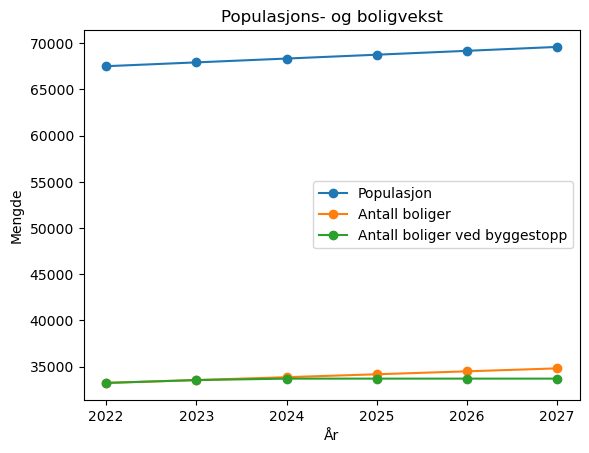

In [7]:
import matplotlib.pyplot as plt
import numpy as np

år = 6
tiden = []
start_år = 2022
for i in range(år):
    tiden.append(start_år+i)

populasjonsvekst = [67520, 67932, 68346, 68763, 69183, 69605]
boligvekst = [33245, 33554, 33866, 34181, 34499, 34820]
boligvekst_byggestopp = [33245, 33554, 33554+((33866-33554)/2), 33554+((33866-33554)/2), 33554+((33866-33554)/2), 33554+((33866-33554)/2)]

plt.plot(tiden,populasjonsvekst, 'o-', label="Populasjon")
plt.plot(tiden,boligvekst, 'o-', label="Antall boliger")
plt.plot(tiden,boligvekst_byggestopp, 'o-', label="Antall boliger ved byggestopp")

plt.xlabel("År")
plt.ylabel("Mengde")
plt.title("Populasjons- og boligvekst")
plt.legend()
plt.show()

For å gi et mer tydelig bilde har jeg her tatt utgangspunkt i antall boliger for å vise graf for populasjonsvekst. Ved en byggestopp vist ved grønn, er veksten halvvert i 2024, og stagnerer fra og med 2025. Vi ser at populasjonsveksten forbigår boligveksten i løpet av 2025, noe som følgelig kan føre til en situasjon hvor etterspørselen etter nye boliger er høyere enn tilbudet.

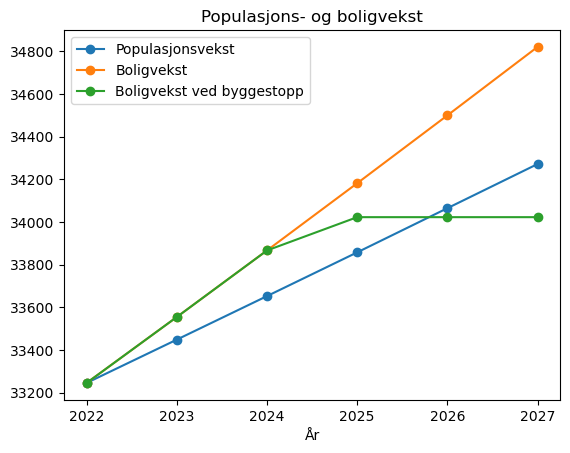

In [8]:
import matplotlib.pyplot as plt
import numpy as np

år = 6
tiden = []
start_år = 2022
for i in range(år):
    tiden.append(start_år+i)

#populasjonsvekst = [67520, 67932, 68346, 68763, 69183, 69605]
populasjonsvekst = [33245, 33448, 33652, 33857, 34064, 34271]
boligvekst = [33245, 33554, 33866, 34181, 34499, 34820]
boligvekst_byggestopp = [33245, 33554, 33866, 33866+((33866-33554)/2), 33866+((33866-33554)/2), 33866+((33866-33554)/2)]

plt.plot(tiden,populasjonsvekst, 'o-', label="Populasjonsvekst")
plt.plot(tiden,boligvekst, 'o-', label="Boligvekst")
plt.plot(tiden,boligvekst_byggestopp, 'o-', label="Boligvekst ved byggestopp")

plt.xlabel("År")
plt.title("Populasjons- og boligvekst")
plt.legend()
plt.show()